In [1]:
%pip install pybamm -q    # install PyBaMM if it is not installed
import pybamm
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
os.chdir(pybamm.__path__[0]+'/..')

Note: you may need to restart the kernel to use updated packages.


In [2]:
model = pybamm.lithium_ion.DFN()
chemistry = pybamm.parameter_sets.Chen2020_plating
parameter_values = pybamm.ParameterValues(chemistry=chemistry)
parameter_values.update({"Ambient temperature [K]": 288.15})

# import drive cycle from file
drive_cycle = pd.read_csv(
    "pybamm/input/drive_cycles/US06.csv", comment="#", header=None
).to_numpy()

# create interpolant
timescale = parameter_values.evaluate(model.timescale)
current_interpolant = pybamm.Interpolant(drive_cycle[:, 0], drive_cycle[:, 1], timescale * pybamm.t)

In [3]:
# set current function
parameter_values["Current function [A]"] = current_interpolant
#t_eval = np.arange(615)

sim = pybamm.Simulation(model, parameter_values=parameter_values, solver=pybamm.CasadiSolver(mode="fast"))
solution1 = sim.solve()
timer = pybamm.Timer()
print(solution1.solve_time)

19.149 s


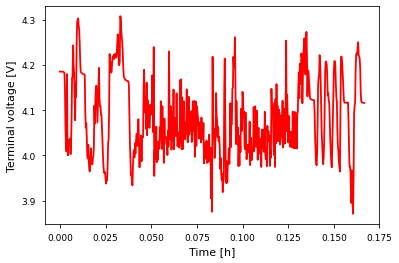

In [4]:
fig, ax = plt.subplots()
t = solution1["Time [h]"].entries
V = solution1["Terminal voltage [V]"].entries
ax.plot(t,V)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Terminal voltage [V]")
plt.show()